# rioxarray

Open file in hard drive (sucks here)

**Activate your environment**

conda activate apeiron

**Update libstdc++-ng**

conda install -c conda-forge libstdcxx-ng=14 -y

**Also make sure all packages come from conda-forge**

conda install -c conda-forge gdal rasterio rioxarray -y

In [30]:
import rioxarray
import xarray as xr
import pystac_client
import planetary_computer as pc

# 1. Connect to the 'Search Engine'
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# 2. Search for a specific patch
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[-122.41, 37.77, -122.43, 37.79], # San Francisco
    datetime="2023-06-01/2023-06-30"
)

# 3. Get the URL for the 'Infrared' card (Band 8)
item = search.item_collection()[0]

# Define the bands you want
# B04 = Red, B03 = Green, B02 = Blue, B08 = Near-Infrared
requested_bands = ["B04", "B03", "B02", "B08"]

# Create a dictionary of signed URLs
band_urls = {}
for band in requested_bands:
    band_urls[band] = pc.sign(item.assets[band].href)

# THIS IS THE STREAMING PART
# It connects to the URL but only fetches a few kilobytes of header data
# Open Red, Green, and Blue streams
datasets = [rioxarray.open_rasterio(band_urls[b], chunks=True) for b in ["B04", "B03", "B02"]]

# Stack them into a 3-channel 'image'
stacked_data = xr.concat(datasets, dim="band")
bounds = raster.rio.bounds()
print(f"Full raster bounds: {bounds}")

# Calculate a small test area (1% of the total area)
minx, miny, maxx, maxy = bounds
width = maxx - minx
height = maxy - miny

# Small test box in the center (10% of width/height)
test_width = width * 0.1
test_height = height * 0.1
center_x = minx + width / 2
center_y = miny + height / 2

test_minx = center_x - test_width / 2
test_maxx = center_x + test_width / 2
test_miny = center_y - test_height / 2
test_maxy = center_y + test_height / 2

print(f"Test area bounds: ({test_minx}, {test_miny}, {test_maxx}, {test_maxy})")

# Extract the patch
patch = stacked_data.rio.clip_box(test_minx, test_miny, test_maxx, test_maxy)

# Only now does the actual 'pixel stream' travel over the internet
data = patch.values

Full raster bounds: (499980.0, 4090200.0, 609780.0, 4200000.0)
Test area bounds: (549390.0, 4139610.0, 560370.0, 4150590.0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1132..1.1936].


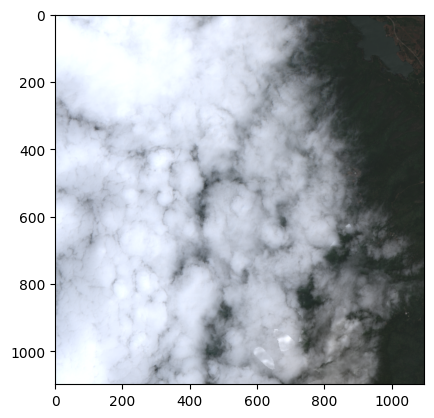

In [35]:
from matplotlib import pyplot as plt
import numpy as np
plt.imshow(np.transpose(data, (1, 2, 0)) / 10000.0)

# stackstac

`🌊 Visible & NIR Bands`

| Asset Key | Common Name | Best Use Case |
|-----------|-------------|---------------|
| B02       | Blue        | Water penetration, bathymetry, smoke/haze |
| B03       | Green       | Vegetation health (green peak), turbid water |
| B04       | Red         | Chlorophyll absorption, urban area mapping |
| B08       | NIR         | The Heavy Lifter. Used for NDVI; shows biomass/plants clearly |
| visual    | True Color  | A pre-rendered RGB image (B04, B03, B02) already processed for the eye |


`🌱 Red Edge & SWIR Bands`

| Asset Key        | Common Name | Best Use Case |
|------------------|-------------|---------------|
| B05, B06, B07    | Red Edge    | "The Red Edge." Critical for precision agriculture (detecting plant stress early) |
| B8A              | Narrow NIR  | Like B08 but ignores water vapor interference. Better for math, worse for "looking pretty" |
| B11              | SWIR 1      | Moisture content in soil/plants; distinguishes snow from clouds |
| B12              | SWIR 2      | Geology, minerals, and advanced moisture mapping |


`☁️ Atmospheric Bands`

| Asset Key | Common Name        | Best Use Case |
|-----------|--------------------|---------------|
| B01       | Coastal Aerosol    | Detects dust/haze |
| B09       | Water Vapor        | Measures atmospheric water vapor |
| B10       | Cirrus             | Detects high-altitude thin clouds |



In [1]:
import os

# 1. Update the environment variable
os.environ["PROJ_LIB"] = "/home/nicholas/miniconda3/envs/apeiron/share/proj"

# 2. Import pyproj and FORCE it to look at the new path
import pyproj
pyproj.datadir.set_data_dir("/home/nicholas/miniconda3/envs/apeiron/share/proj")

# 3. VERIFY - If this prints, your problem is solved. 
# If it crashes here, the path itself is wrong.
from pyproj import CRS
print(CRS.from_epsg(4326))

EPSG:4326


/home/nicholas/miniconda3/envs/apeiron/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import pystac_client
import planetary_computer as pc
import stackstac
import xarray as xr
import numpy as np

# --- STEP 1: DEFINE THE GENERAL REGION ---
# This is the "Large Slide" we stream from the cloud (San Francisco area)
# [West, South, East, North]
# -122.53 is further West (Left) than -122.41
size = 0.1
langtitude = 100.81749
longtitude = 31.135815
general_bbox = [langtitude, longtitude, langtitude + size, longtitude + size]

catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=general_bbox, 
    datetime="2023-06-01/2023-06-30"
)

# Grab the first available clear image and sign it
item = search.item_collection()[0]
signed_item = pc.sign(item)

# --- STEP 2: STREAM THE DATA ---
cube = stackstac.stack(
    signed_item,
    assets=["B04", "B03", "B02"],
    bounds_latlon=general_bbox,
    epsg=32610,
    chunksize=512,
)

# Pull into memory and convert to 0.0 - 1.0 reflectance
patch = cube.compute()
# Remove the 'time' dimension: (Channels, Height, Width)
data = patch.values.astype("float32")[0] / 10000.0

Final Shape: (3, 1046, 995)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1006..1.0056].


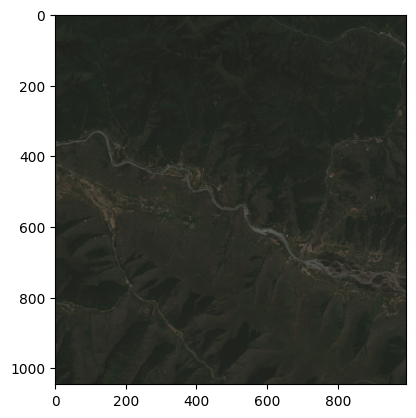

In [3]:
# --- STEP 3: SURGICAL CROP (Normalized XYXY) ---
# xyxy_norm = [xmin, ymin, xmax, ymax] from 0.0 to 1.0
def get_surgical_patch(large_array, xyxy_norm):
    channels, h, w = large_array.shape
    x1, y1, x2, y2 = xyxy_norm
    
    # Calculate pixel indices
    left, right = int(x1 * w), int(x2 * w)
    top, bottom = int(y1 * h), int(y2 * h)
    
    return large_array[:, top:bottom, left:right]

# Example: Surgical crop of the Golden Gate Bridge area within your SF patch
# These are just example percentages!
my_target = [0.0, 0.0, 1.0, 1.0] 
surgical_data = get_surgical_patch(data, my_target)

print(f"Final Shape: {surgical_data.shape}")

from matplotlib import pyplot as plt
import numpy as np
plt.imshow(np.transpose(surgical_data[-3:], (1, 2, 0)))

In [12]:
data.shape

(3, 1320, 1050)

In [8]:
np.transpose(surgical_data[-3:], (1, 2, 0)).shape

(1320, 1050, 3)